In [1]:
!pip install -q augly
!pip install -q librosa
# Mount drive if not already mounted
import google.colab.drive as drive
import os
if not os.path.exists('/content/drive'):
  drive.mount('/content/drive')
import re
import librosa
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import sys

# Fix for augly/torchaudio compatibility in Python 3.12 / Torchaudio 2.x
import torchaudio

# Define a mock class to replace the missing sox_effects module
class SoxPatch:
    @staticmethod
    def apply_effects_tensor(tensor, sample_rate, effects, channels_first=True):
        # Most augly transforms just need the tensor returned if sox isn't handling it
        return tensor, sample_rate
# Inject the patch into sys.modules so augly can find it
if not hasattr(torchaudio, 'sox_effects'):
    mock_sox = SoxPatch()
    sys.modules['torchaudio.sox_effects'] = mock_sox
    torchaudio.sox_effects = mock_sox

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 43.5 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
!git clone https://github.com/mona0101/Final-year-project-2026.git
%cd Final-year-project-2026

Cloning into 'Final-year-project-2026'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 60 (delta 30), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 157.16 KiB | 5.42 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/Final-year-project-2026


In [3]:
import torch
import os
from dataset_loader2 import DroneFusionDataset, get_loader
from augmentation import get_audio_transform, get_img_transform, get_rf_transform
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 1. الإعدادات الأساسية
class Args:
    dataset_dir = '/content/drive/MyDrive/Colab Notebooks'
    crop_size = 112
    batch_size = 32
    num_workers = 0

args = Args()

def prepare_drone_dataloaders(args, feature_type='mfcc', modalities=['audio'], n_mels=64, hop_length=512):
    """
    تجهيز الـ Loaders مع طباعة الأبعاد وعدد البيانات للتأكد
    """
    # 1. Define Transforms
    train_trans = {
        'audio': get_audio_transform(args, is_training=True, feature_type=feature_type),
        'video': get_img_transform(args, is_training=True, augment=False),
        'rf': get_rf_transform(args, is_training=True, augment=False)
    }

    val_trans = {
        'audio': get_audio_transform(args, is_training=False, feature_type=feature_type),
        'video': get_img_transform(args, is_training=False, augment=False),
        'rf': get_rf_transform(args, is_training=False, augment=False)
    }

    # 2. Paths
    audio_root = os.path.join(args.dataset_dir, 'Audio')
    video_root = os.path.join(args.dataset_dir, 'Video')
    rf_root = os.path.join(args.dataset_dir, 'RF_Spectrograms')

    # 3. Create Datasets helper
    def make_ds(split):
        return DroneFusionDataset(
            audio_root=f"{audio_root}/{split}",
            video_root=f"{video_root}/{split}",
            rf_root=f"{rf_root}/{split}",
            dataset_type=split,
            transform=train_trans if split == 'Train' else val_trans,
            audio_feature_type=feature_type,
            n_mels=n_mels,
            hop_length=hop_length,
            modalities=modalities
        )

    # 4. Initialize Splits
    train_ds = make_ds('Train')
    val_ds   = make_ds('Validation')
    test_ds  = make_ds('Test')

    # 5. Create Loaders
    loaders = {
        'train': get_loader(train_ds, batch_size=args.batch_size, is_train=True),
        'val':   get_loader(val_ds,   batch_size=args.batch_size, is_train=False),
        'test':  get_loader(test_ds,  batch_size=args.batch_size, is_train=False)
    }

    # --- فحص الأبعاد والعدد (Direct Check) ---
    sample_batch = next(iter(loaders['train']))
    input_shape = sample_batch[0].shape

    print(f"Dataloaders Ready | Feature: {feature_type.upper()}")
    print(f"Samples -> Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    print(f"Tensor Shape: {input_shape} (Batch, Channel, Height, Width)")
    # ----------------------------------------

    return loaders

In [4]:
# ==========================================
# MODULAR TRAINING & EVALUATION (STATIC LABELS + LATENCY)
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)
import copy
import time

# --------------------------
# 1️⃣ Training Function
# --------------------------
def train_unimodal(model, dataloaders, device, criterion, optimizer, num_epochs=10, modal_num=0):
    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc']}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        for phase in ['train','val']:
            model.train() if phase=='train' else model.eval()
            running_loss, all_preds, all_labels = 0.0, [], []

            for batch in tqdm(dataloaders[phase], desc=f"{phase.upper()}", leave=False):
                inputs = batch[modal_num].to(device).float()
                labels = batch[-1].to(device).float()

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase=='train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    if phase=='train':
                        loss.backward()

                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                preds = (outputs>0.5).long()
                all_preds.append(preds.detach())
                all_labels.append(labels.detach().long())

            # Metrics
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            y_true = torch.cat(all_labels).cpu().numpy()
            y_pred = torch.cat(all_preds).cpu().numpy()
            epoch_acc = accuracy_score(y_true, y_pred)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f"{phase.upper()} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            # Save best model
            if phase=='val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f"Saved best model weights (Acc: {best_acc:.4f})")

    model.load_state_dict(best_model_wts)
    return model, history

# --------------------------
# 2️⃣ Testing Function (with latency)
# --------------------------
def test_unimodal(model, dataloader, device, modal_num=0, dataset_name="Dataset"):
    model.eval()
    all_preds, all_labels = [], []
    total_time, total_samples = 0, 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Testing {dataset_name}"):
            inputs = batch[modal_num].to(device).float()
            labels = batch[-1].to(device).long()

            # Timing
            if device.type=='cuda': torch.cuda.synchronize()
            start = time.time()
            outputs = model(inputs)
            if device.type=='cuda': torch.cuda.synchronize()
            total_time += (time.time()-start)

            preds = (outputs>0.5).long()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            total_samples += inputs.size(0)

    # Metrics
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    avg_ms = (total_time / total_samples) * 1000
    fps = 1000 / avg_ms

    print(f"\n===== {dataset_name} Results =====")
    print(f"Accuracy: {accuracy:.4f} | F1 (macro): {f1.mean():.4f}")
    print(f"Latency: {avg_ms:.2f} ms/sample | FPS: {fps:.2f}")
    print("===============================\n")

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'avg_ms': avg_ms,
        'fps': fps
    }

# --------------------------
# 3️⃣ Plot Training History
# --------------------------
def plot_training_history(history):
    epochs = range(1,len(history['train_loss'])+1)
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'],  label='Val Loss')
    plt.title("Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title("Accuracy vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

# --------------------------
# 4️⃣ Confusion Matrix
# --------------------------
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    class_names = ["No-Drone","Drone"]
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# --------------------------
# 5️⃣ Per-Class Metrics Bar Plot
# --------------------------
def plot_per_class_metrics_group(y_true, y_pred, dataset_name="Dataset"):
    class_names = ["No-Drone","Drone"]
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    accuracy = [accuracy_score(y_true, y_pred)]*len(class_names)

    paired_colors = ['#1f78b4','#a6cee3','#b2df8a','#33a02c']
    x = np.arange(len(class_names))
    width = 0.2

    plt.figure(figsize=(8,5))
    plt.bar(x-1.5*width, precision, width, label="Precision", color=paired_colors[0])
    plt.bar(x-0.5*width, recall, width, label="Recall", color=paired_colors[1])
    plt.bar(x+0.5*width, f1, width, label="F1-score", color=paired_colors[2])
    plt.bar(x+1.5*width, accuracy, width, label="Accuracy", color=paired_colors[3])
    plt.xticks(x,class_names)
    plt.ylim(0,1)
    plt.ylabel("Score")
    plt.title(f"Per-Class Metrics ({dataset_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --------------------------
# 6️⃣ Classification Report
# --------------------------
def print_classification_report(y_true, y_pred, dataset_name="Dataset"):
    class_names = ["No-Drone","Drone"]
    print(f"\n===== {dataset_name} Classification Report =====")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MFCC 40*40

In [16]:
class MFCCCNN(nn.Module):
    def __init__(self):
        super(MFCCCNN, self).__init__()

        # Conv Block 1
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        # Conv Block 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Conv Block 3
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout
        self.dropout = nn.Dropout(0.5)

        # بعد 3 Pooling من 40x40 -> 20x20 -> 10x10 -> 5x5
        self.fc1 = nn.Linear(64 * 5 * 5, 128)

        # طبقة الإخراج متوافقة مع BCELoss
        self.classifier = nn.Sequential(
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: [batch, 1, 40, 40]

        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # [batch,16,20,20]
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # [batch,32,10,10]
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # [batch,64,5,5]

        x = x.view(x.size(0), -1)  # Flatten

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        out = self.classifier(x)

        return out.squeeze()  # [batch] لتتوافق مع الـ labels


Preparing MFCC Data...
Dataloaders Ready | Feature: MFCC
Samples -> Train: 8480, Val: 1280, Test: 1320
Tensor Shape: torch.Size([32, 1, 40, 40]) (Batch, Channel, Height, Width)

Epoch 1/10


TRAIN -> Loss: 0.5931 | Acc: 0.6802


VAL -> Loss: 0.7015 | Acc: 0.5875
Saved best model weights (Acc: 0.5875)

Epoch 2/10


TRAIN -> Loss: 0.5441 | Acc: 0.7157


VAL -> Loss: 0.9597 | Acc: 0.5219

Epoch 3/10


...

VAL -> Loss: 1.0298 | Acc: 0.5680

Epoch 9/10


TRAIN -> Loss: 0.4790 | Acc: 0.7504


VAL -> Loss: 0.9694 | Acc: 0.5781

Epoch 10/10


TRAIN -> Loss: 0.4720 | Acc: 0.7546


VAL -> Loss: 0.9145 | Acc: 0.5977


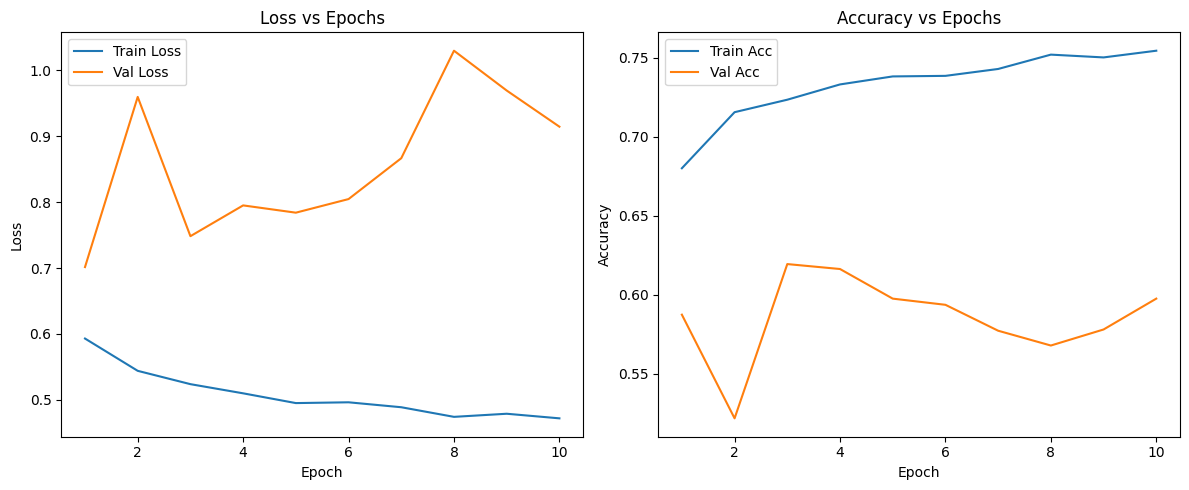

Testing Train: 100%|██████████| 265/265 [07:10<00:00,  1.62s/it]



===== Train Results =====
Accuracy: 0.7342 | F1 (macro): 0.7336
Latency: 0.05 ms/sample | FPS: 19140.74



Testing Validation: 100%|██████████| 40/40 [00:12<00:00,  3.33it/s]



===== Validation Results =====
Accuracy: 0.6195 | F1 (macro): 0.6129
Latency: 0.05 ms/sample | FPS: 20135.58



Testing Test: 100%|██████████| 42/42 [00:12<00:00,  3.45it/s]



===== Test Results =====
Accuracy: 0.6212 | F1 (macro): 0.6169
Latency: 0.07 ms/sample | FPS: 13802.83


===== Train Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.6750    0.7723    0.7204      3760
       Drone     0.7951    0.7038    0.7467      4720

    accuracy                         0.7342      8480
   macro avg     0.7351    0.7381    0.7336      8480
weighted avg     0.7419    0.7342    0.7350      8480


===== Validation Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.4964    1.0000    0.6634       480
       Drone     1.0000    0.3912    0.5624       800

    accuracy                         0.6195      1280
   macro avg     0.7482    0.6956    0.6129      1280
weighted avg     0.8111    0.6195    0.6003      1280


===== Test Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.4898    1.0000    0.6575       480
     

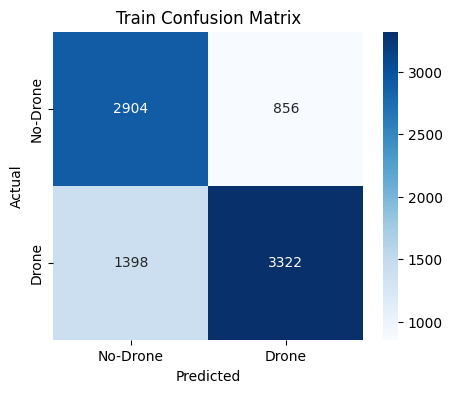

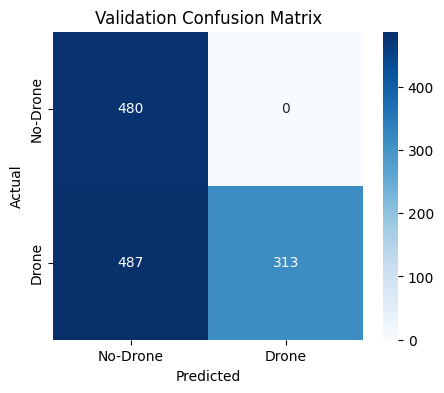

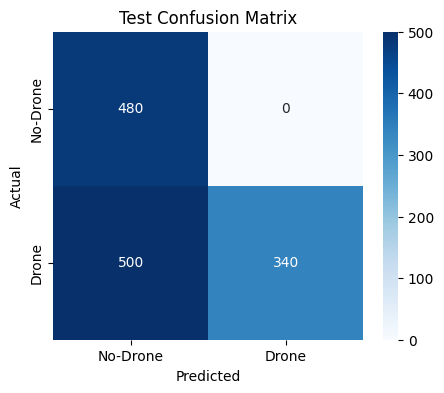

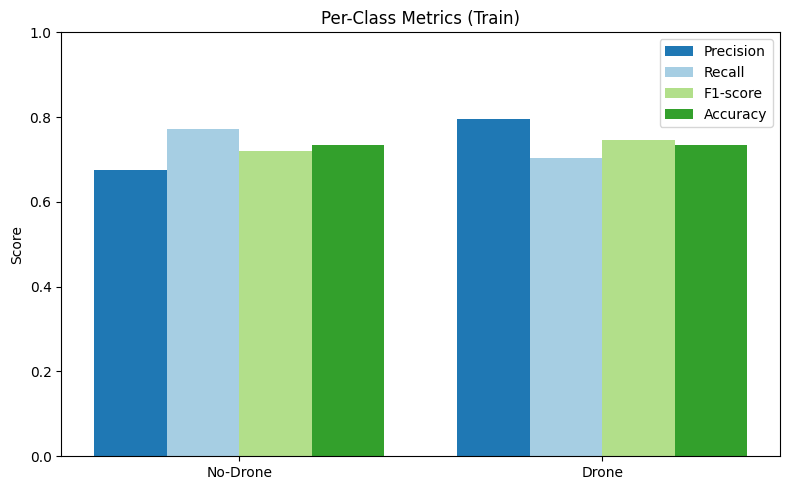

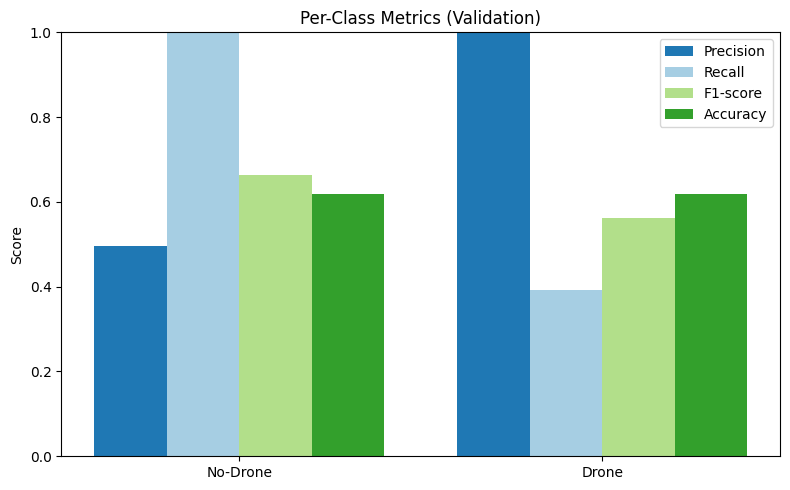

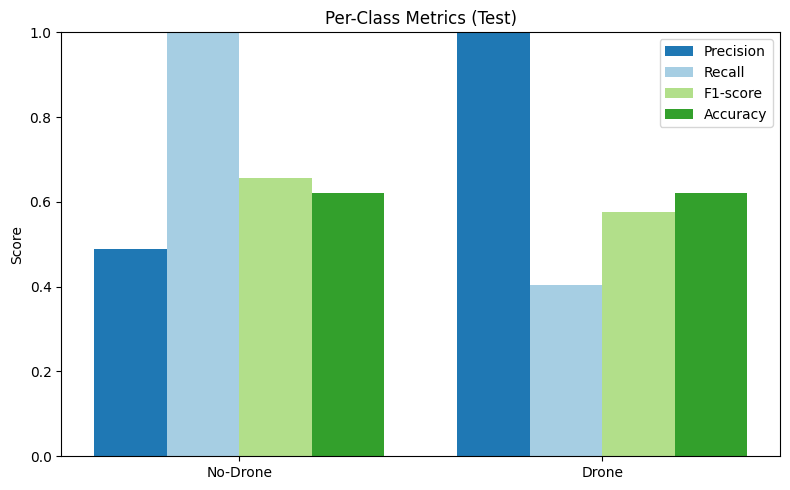

In [17]:
# 1. تجهيز البيانات
print("Preparing MFCC Data...")
loaders_mfcc = prepare_drone_dataloaders(args, feature_type='mfcc')

model = MFCCCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# 3️⃣ Training
model, history = train_unimodal(model, loaders_mfcc, device, criterion, optimizer, num_epochs=10)

# 2️⃣ رسم loss و accuracy
plot_training_history(history)

# 3️⃣ اختبار كل مجموعة بيانات (مع حساب الوقت)
train_metrics = test_unimodal(model, loaders_mfcc['train'], device, dataset_name="Train")
val_metrics   = test_unimodal(model, loaders_mfcc['val'], device, dataset_name="Validation")
test_metrics  = test_unimodal(model, loaders_mfcc['test'], device, dataset_name="Test")

# 4️⃣ طباعة classification reports
print_classification_report(train_metrics['y_true'], train_metrics['y_pred'], "Train")
print_classification_report(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
print_classification_report(test_metrics['y_true'], test_metrics['y_pred'], "Test")

# 5️⃣ رسم مصفوفة الالتباس لكل مجموعة
plot_confusion_matrix(train_metrics['y_true'], train_metrics['y_pred'], "Train Confusion Matrix")
plot_confusion_matrix(val_metrics['y_true'], val_metrics['y_pred'], "Validation Confusion Matrix")
plot_confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], "Test Confusion Matrix")

# 6️⃣ رسم per-class metrics

plot_per_class_metrics_group(train_metrics['y_true'], train_metrics['y_pred'], "Train")
plot_per_class_metrics_group(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
plot_per_class_metrics_group(test_metrics['y_true'], test_metrics['y_pred'], "Test")

Log mel 128*40

In [8]:
class LogMelCNN(nn.Module):
    def __init__(self):
        super(LogMelCNN, self).__init__()

        # الطبقة التلافيفية الأولى: تعالج الـ Log-Mel [1, 128, 40]
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # الطبقة التلافيفية الثانية
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # الطبقة التلافيفية الثالثة
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # طبقة التجميع (Pooling) لتقليل الأبعاد المكانية
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout لمنع الإفراط في التخصيص (Overfitting)
        self.dropout = nn.Dropout(0.5)

        # حساب الحجم النهائي بعد 3 عمليات Pooling:
        # الارتفاع: 128 -> 64 -> 32 -> 16
        # العرض: 40 -> 20 -> 10 -> 5
        # 128 (channels) * 16 * 5 = 10240
        self.fc1 = nn.Linear(128 * 16 * 5, 256)

        # الطبقة الأخيرة متوافقة مع BCELoss (مخرج واحد + Sigmoid)
        self.classifier = nn.Sequential(
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: [batch, 1, 128, 40]

        # Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # [32, 64, 20]

        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # [64, 32, 10]

        # Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x)))) # [128, 16, 5]

        # Flatten
        x = x.view(x.size(0), -1)

        # Dense Layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # Output layer with Sigmoid
        out = self.classifier(x)

        return out.squeeze() # إزالة الأبعاد الزائدة لتتوافق مع Labels الـ Batch

Preparing Log-Mel 128 Data...
Dataloaders Ready | Feature: LOGMEL
Samples -> Train: 8480, Val: 1280, Test: 1320
Tensor Shape: torch.Size([32, 1, 128, 40]) (Batch, Channel, Height, Width)

Epoch 1/10


TRAIN -> Loss: 0.4609 | Acc: 0.7717


VAL -> Loss: 0.2744 | Acc: 0.8812
Saved best model weights (Acc: 0.8812)

Epoch 2/10


TRAIN -> Loss: 0.3783 | Acc: 0.8241


VAL -> Loss: 0.2411 | Acc: 0.8992
Saved best model weights (Acc: 0.8992)

Epoch 3/10


...

VAL -> Loss: 0.1667 | Acc: 0.9352
Saved best model weights (Acc: 0.9352)

Epoch 9/10


TRAIN -> Loss: 0.2716 | Acc: 0.8708


VAL -> Loss: 0.1596 | Acc: 0.9320

Epoch 10/10


TRAIN -> Loss: 0.2612 | Acc: 0.8815


VAL -> Loss: 0.1792 | Acc: 0.9352


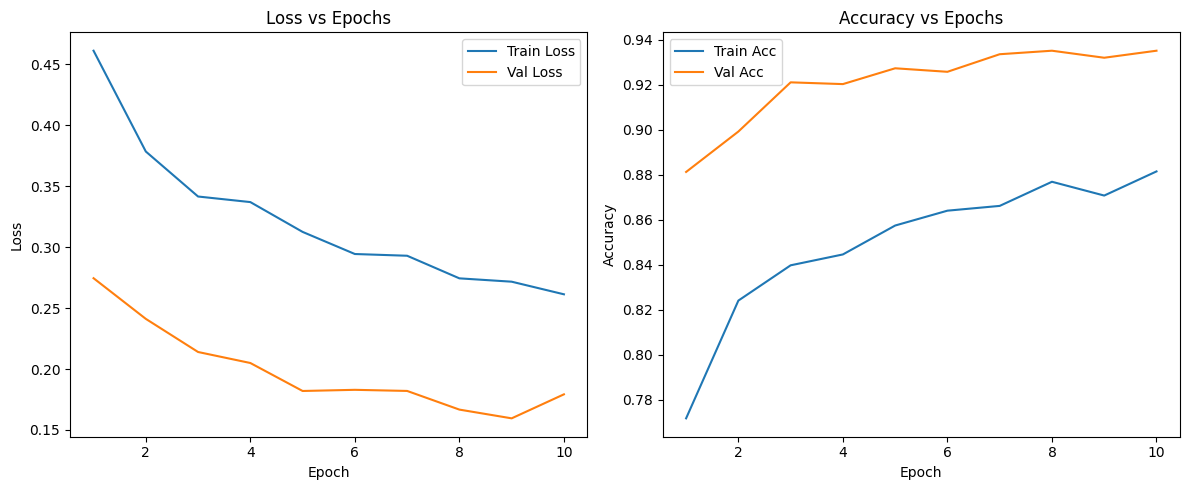

Testing Train: 100%|██████████| 265/265 [01:30<00:00,  2.93it/s]



===== Train Results =====
Accuracy: 0.8884 | F1 (macro): 0.8872
Latency: 0.09 ms/sample | FPS: 10848.54



Testing Validation: 100%|██████████| 40/40 [00:12<00:00,  3.25it/s]



===== Validation Results =====
Accuracy: 0.9352 | F1 (macro): 0.9317
Latency: 0.09 ms/sample | FPS: 10597.51



Testing Test: 100%|██████████| 42/42 [01:20<00:00,  1.91s/it]


===== Test Results =====
Accuracy: 0.9144 | F1 (macro): 0.9105
Latency: 0.11 ms/sample | FPS: 9483.30


===== Train Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.8668    0.8843    0.8755      3760
       Drone     0.9063    0.8917    0.8990      4720

    accuracy                         0.8884      8480
   macro avg     0.8866    0.8880    0.8872      8480
weighted avg     0.8888    0.8884    0.8885      8480


===== Validation Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.8869    0.9479    0.9164       480
       Drone     0.9674    0.9275    0.9470       800

    accuracy                         0.9352      1280
   macro avg     0.9272    0.9377    0.9317      1280
weighted avg     0.9372    0.9352    0.9356      1280


===== Test Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.8259    0.9688    0.8917       480
      

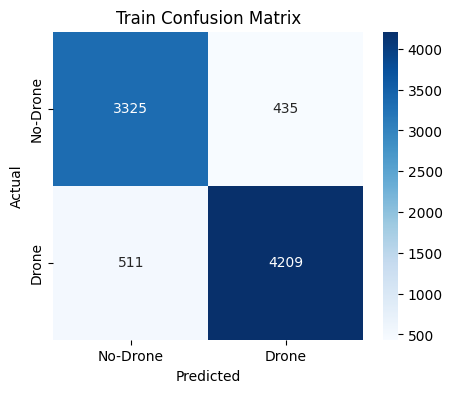

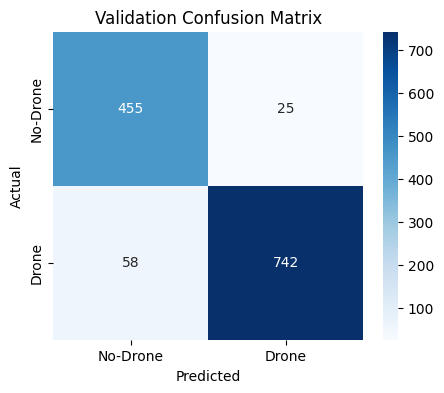

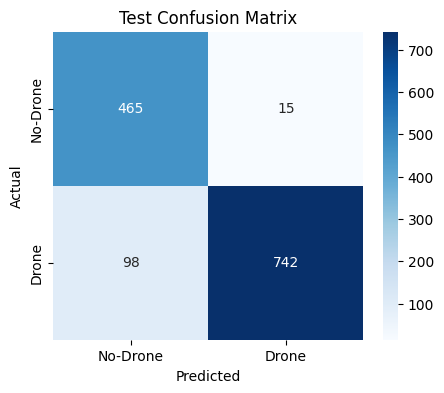

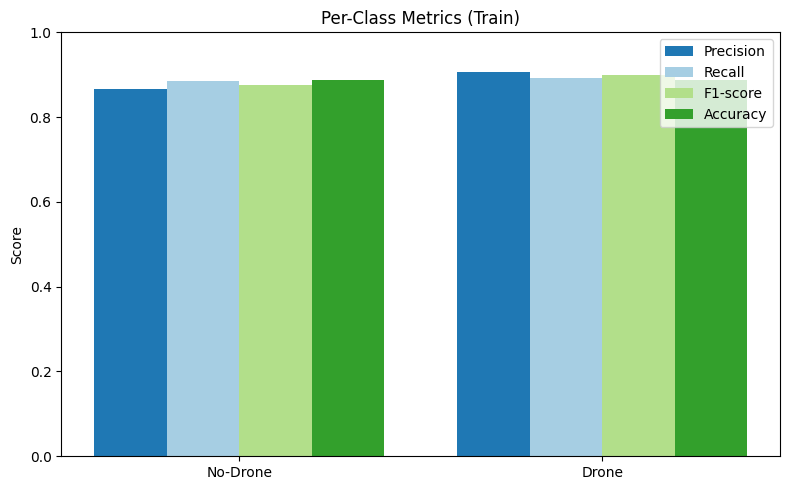

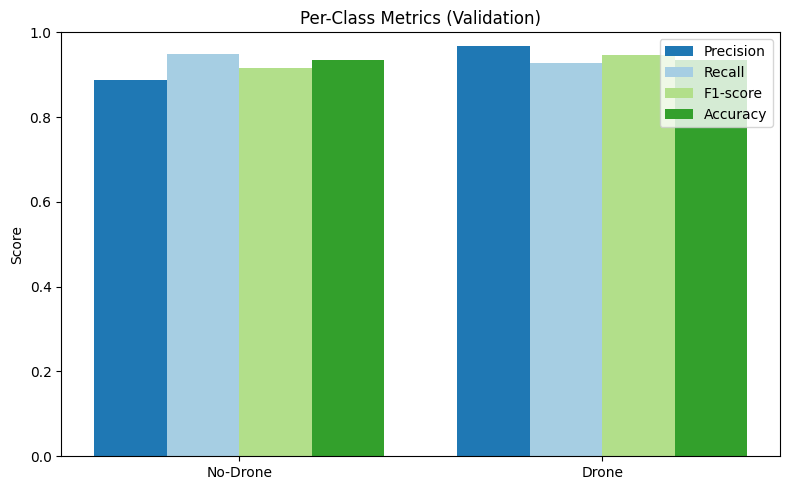

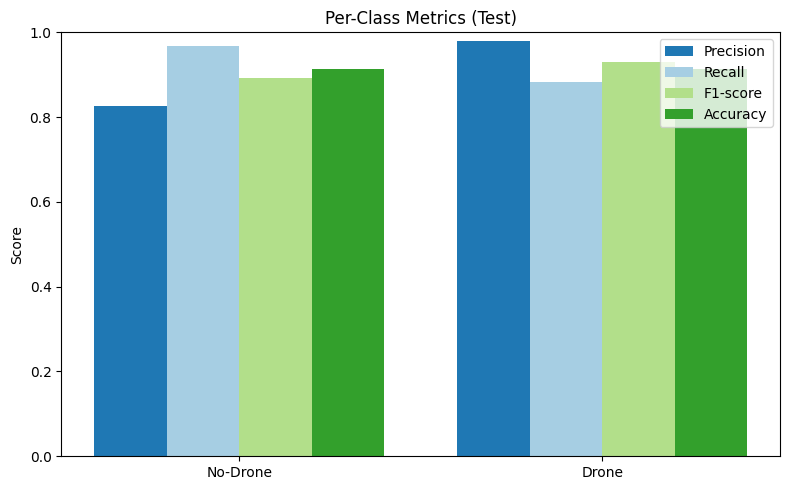

In [11]:

# 1. تجهيز البيانات (بإعدادات 128 Mel bins)
print("Preparing Log-Mel 128 Data...")
# إعداد الجهاز (GPU if available)

loaders_mel128 = prepare_drone_dataloaders(
    args,
    feature_type='logmel',
    n_mels=128,
    hop_length=138
)


# 1️⃣ التدريب
model = LogMelCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# 3️⃣ Training
model, history = train_unimodal(model, loaders_mel128, device, criterion, optimizer, num_epochs=10)

# 2️⃣ رسم loss و accuracy
plot_training_history(history)

# 3️⃣ اختبار كل مجموعة بيانات (مع حساب الوقت)
train_metrics = test_unimodal(model, loaders_mel128['train'], device, dataset_name="Train")
val_metrics   = test_unimodal(model, loaders_mel128['val'], device, dataset_name="Validation")
test_metrics  = test_unimodal(model, loaders_mel128['test'], device, dataset_name="Test")

# 4️⃣ طباعة classification reports
print_classification_report(train_metrics['y_true'], train_metrics['y_pred'], "Train")
print_classification_report(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
print_classification_report(test_metrics['y_true'], test_metrics['y_pred'], "Test")

# 5️⃣ رسم مصفوفة الالتباس لكل مجموعة
plot_confusion_matrix(train_metrics['y_true'], train_metrics['y_pred'], "Train Confusion Matrix")
plot_confusion_matrix(val_metrics['y_true'], val_metrics['y_pred'], "Validation Confusion Matrix")
plot_confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], "Test Confusion Matrix")

# 6️⃣ رسم per-class metrics

plot_per_class_metrics_group(train_metrics['y_true'], train_metrics['y_pred'], "Train")
plot_per_class_metrics_group(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
plot_per_class_metrics_group(test_metrics['y_true'], test_metrics['y_pred'], "Test")


Log mel 64*40

In [12]:
class LogMelCNN_64(nn.Module):
    def __init__(self):
        super(LogMelCNN_64, self).__init__()

        # Conv Block 1: 64x40 -> 32x20 (after pool)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Conv Block 2: 32x20 -> 16x10 (after pool)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Conv Block 3: 16x10 -> 8x5 (after pool)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)

        # Flattened size: 128 channels * 8 height * 5 width = 5120
        self.fc1 = nn.Linear(128 * 8 * 5, 256)

        self.classifier = nn.Sequential(
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: [batch, 1, 64, 40]
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        out = self.classifier(x)
        return out.squeeze()

Preparing Log-Mel 64 Data...
Dataloaders Ready | Feature: LOGMEL
Samples -> Train: 8480, Val: 1280, Test: 1320
Tensor Shape: torch.Size([32, 1, 64, 40]) (Batch, Channel, Height, Width)

Epoch 1/10


TRAIN -> Loss: 0.4541 | Acc: 0.7836


VAL -> Loss: 0.2644 | Acc: 0.8945
Saved best model weights (Acc: 0.8945)

Epoch 2/10


TRAIN -> Loss: 0.3737 | Acc: 0.8338


VAL -> Loss: 0.2064 | Acc: 0.9227
Saved best model weights (Acc: 0.9227)

Epoch 3/10


...

VAL -> Loss: 0.1471 | Acc: 0.9437

Epoch 9/10


TRAIN -> Loss: 0.2498 | Acc: 0.8874


VAL -> Loss: 0.1616 | Acc: 0.9328

Epoch 10/10


TRAIN -> Loss: 0.2407 | Acc: 0.8900


VAL -> Loss: 0.1436 | Acc: 0.9547
Saved best model weights (Acc: 0.9547)


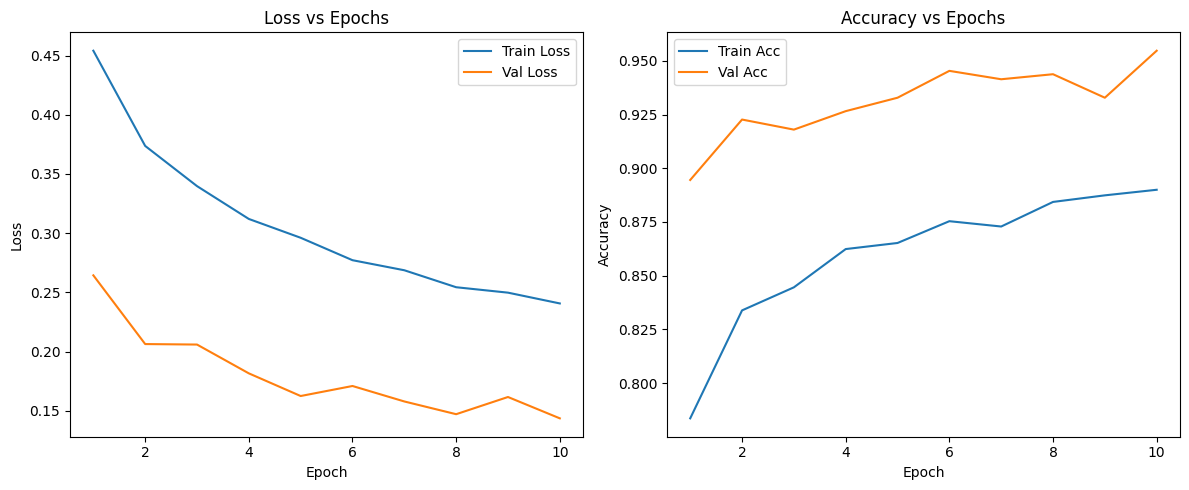

Testing Train: 100%|██████████| 265/265 [01:20<00:00,  3.30it/s]



===== Train Results =====
Accuracy: 0.9086 | F1 (macro): 0.9074
Latency: 0.06 ms/sample | FPS: 17602.08



Testing Validation: 100%|██████████| 40/40 [00:11<00:00,  3.60it/s]



===== Validation Results =====
Accuracy: 0.9547 | F1 (macro): 0.9520
Latency: 0.06 ms/sample | FPS: 16258.12



Testing Test: 100%|██████████| 42/42 [00:11<00:00,  3.70it/s]



===== Test Results =====
Accuracy: 0.9356 | F1 (macro): 0.9320
Latency: 0.06 ms/sample | FPS: 16187.12


===== Train Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.8966    0.8973    0.8970      3760
       Drone     0.9182    0.9176    0.9179      4720

    accuracy                         0.9086      8480
   macro avg     0.9074    0.9075    0.9074      8480
weighted avg     0.9086    0.9086    0.9086      8480


===== Validation Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.9254    0.9563    0.9406       480
       Drone     0.9732    0.9537    0.9634       800

    accuracy                         0.9547      1280
   macro avg     0.9493    0.9550    0.9520      1280
weighted avg     0.9553    0.9547    0.9548      1280


===== Test Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.8692    0.9688    0.9163       480
     

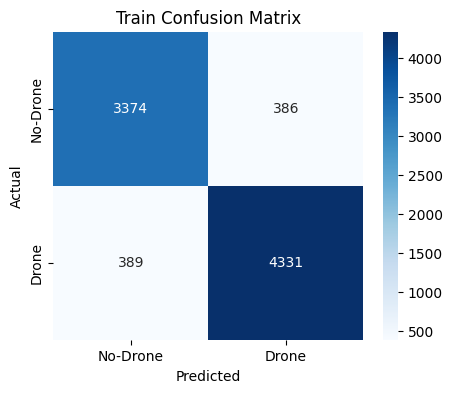

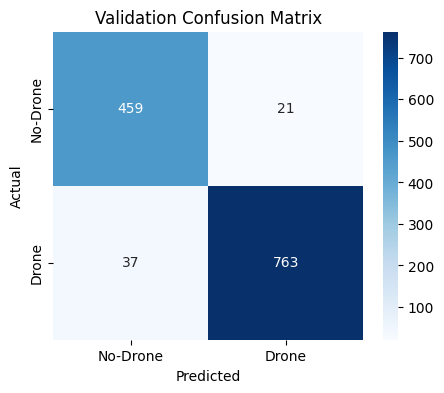

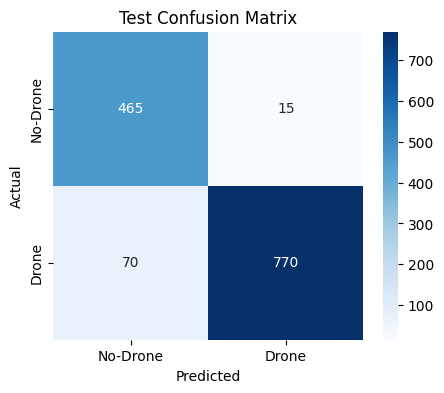

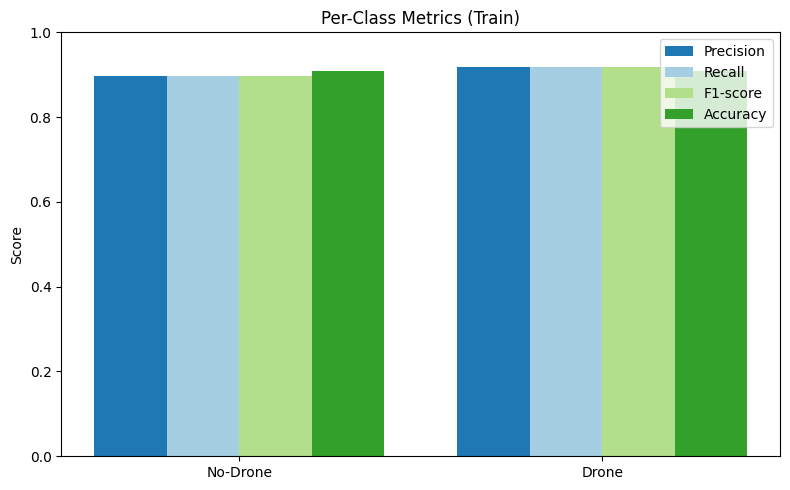

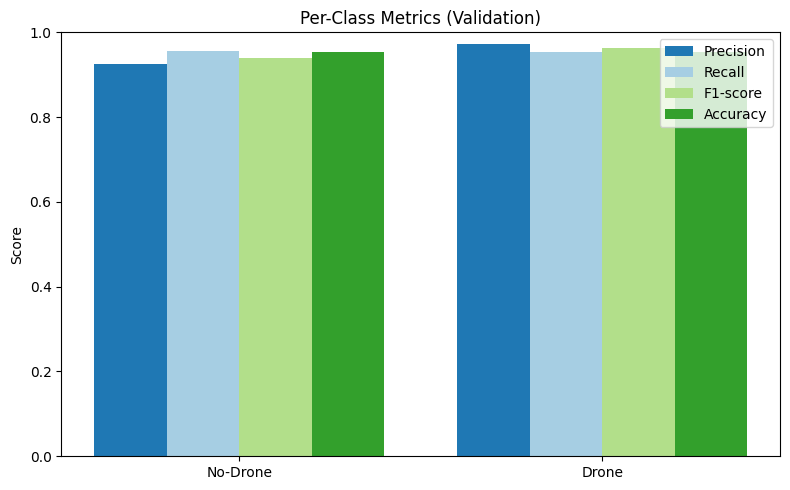

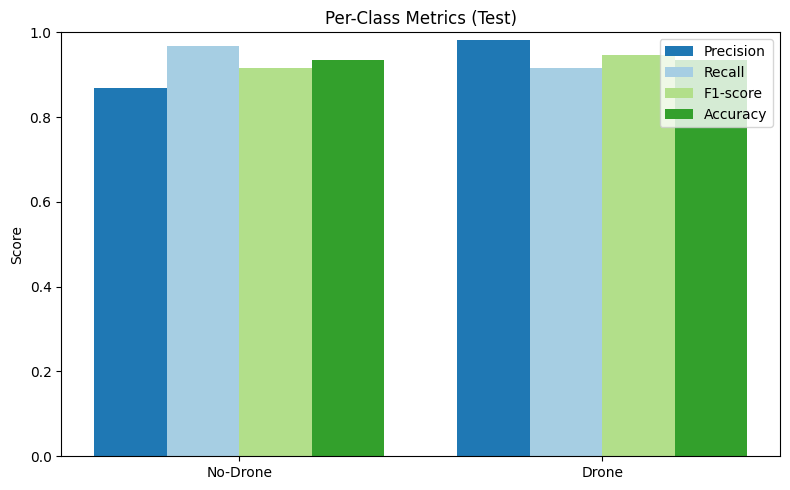

In [14]:
# 1. تجهيز البيانات (بإعدادات 64 Mel bins)
print("Preparing Log-Mel 64 Data...")
loaders_mel64 = prepare_drone_dataloaders(
    args,
    feature_type='logmel',
    n_mels=64,
    hop_length=138
)


# 1️⃣ التدريب
model = LogMelCNN_64().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# 3️⃣ Training
model, history = train_unimodal(model, loaders_mel64, device, criterion, optimizer, num_epochs=10)

# 2️⃣ رسم loss و accuracy
plot_training_history(history)

# 3️⃣ اختبار كل مجموعة بيانات (مع حساب الوقت)
train_metrics = test_unimodal(model, loaders_mel64['train'], device, dataset_name="Train")
val_metrics   = test_unimodal(model, loaders_mel64['val'], device, dataset_name="Validation")
test_metrics  = test_unimodal(model, loaders_mel64['test'], device, dataset_name="Test")

# 4️⃣ طباعة classification reports
print_classification_report(train_metrics['y_true'], train_metrics['y_pred'], "Train")
print_classification_report(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
print_classification_report(test_metrics['y_true'], test_metrics['y_pred'], "Test")

# 5️⃣ رسم مصفوفة الالتباس لكل مجموعة
plot_confusion_matrix(train_metrics['y_true'], train_metrics['y_pred'], "Train Confusion Matrix")
plot_confusion_matrix(val_metrics['y_true'], val_metrics['y_pred'], "Validation Confusion Matrix")
plot_confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], "Test Confusion Matrix")

# 6️⃣ رسم per-class metrics

plot_per_class_metrics_group(train_metrics['y_true'], train_metrics['y_pred'], "Train")
plot_per_class_metrics_group(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
plot_per_class_metrics_group(test_metrics['y_true'], test_metrics['y_pred'], "Test")